Cell 1 — Import library dan konfigurasi path

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

import plotly.graph_objects as go
from IPython.display import display

try:
    import ipywidgets as widgets
    from IPython.display import clear_output
    WIDGET_AVAILABLE = True
except Exception:
    WIDGET_AVAILABLE = False

# =========================
# CONFIG FILE
# =========================

FILE_PATH = Path("/media/spell/Spell-lab/Lidar/C.Framed Dataset/Dataset Development/Jatuh/Dilia/3.csv")

# Kolom wajib hasil frame builder
REQUIRED_COLUMNS = ["frame_id", "Timestamp", "X", "Y", "Z", "Reflectivity"]

# =========================
# VISUALIZATION CONFIG
# =========================

# False = tampilkan seluruh point cloud pada frame
# True  = tampilkan hanya titik dalam ROI
USE_ROI_FILTER = True

# ROI sesuai skema proyek
ROI_X_MIN, ROI_X_MAX = 0.0, 3.0
ROI_Y_MIN, ROI_Y_MAX = -1.5, 1.5
ROI_Z_MIN, ROI_Z_MAX = 0.0, 2.0

# Batas jumlah titik yang diplot agar Plotly tidak terlalu berat
# 1 frame raw normal = 19,968 points, jadi 20,000 masih aman.
MAX_POINTS_PLOT = 20000

# Marker visual
MARKER_SIZE = 2
MARKER_OPACITY = 0.85

print("===== POINT CLOUD FRAME VISUALIZATION CONFIG =====")
print("File path:", FILE_PATH)
print("File exists:", FILE_PATH.exists())
print("Use ROI filter:", USE_ROI_FILTER)
print("Max points per plot:", MAX_POINTS_PLOT)

print("\nROI setting:")
print(f"X: {ROI_X_MIN} to {ROI_X_MAX}")
print(f"Y: {ROI_Y_MIN} to {ROI_Y_MAX}")
print(f"Z: {ROI_Z_MIN} to {ROI_Z_MAX}")

print("\nWidget available:", WIDGET_AVAILABLE)

===== POINT CLOUD FRAME VISUALIZATION CONFIG =====
File path: /media/spell/Spell-lab/Lidar/C.Framed Dataset/Dataset Development/Jatuh/Dilia/3.csv
File exists: True
Use ROI filter: True
Max points per plot: 20000

ROI setting:
X: 0.0 to 3.0
Y: -1.5 to 1.5
Z: 0.0 to 2.0

Widget available: True


Cell 2 — Load CSV dan validasi kolom

In [3]:
# =========================
# LOAD AND VALIDATE FRAMED CSV
# =========================

if not FILE_PATH.exists():
    raise FileNotFoundError(f"File tidak ditemukan: {FILE_PATH}")

df = pd.read_csv(FILE_PATH)

print("===== RAW LOADED DATA =====")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

missing_cols = [col for col in REQUIRED_COLUMNS if col not in df.columns]
if missing_cols:
    raise ValueError(f"Kolom wajib tidak ditemukan: {missing_cols}")

# Ambil hanya kolom yang diperlukan untuk visualisasi
df = df[REQUIRED_COLUMNS].copy()

# Numeric safety
for col in REQUIRED_COLUMNS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

before_drop = len(df)
df = df.dropna(subset=REQUIRED_COLUMNS).copy()
after_drop = len(df)

df["frame_id"] = df["frame_id"].astype(int)
df = df.sort_values(["frame_id", "Timestamp"]).reset_index(drop=True)

print("\n===== CLEANED DATA FOR VISUALIZATION =====")
print("Rows before drop NaN:", before_drop)
print("Rows after drop NaN :", after_drop)
print("Dropped rows        :", before_drop - after_drop)
print("Number of frames    :", df["frame_id"].nunique())
print("Frame ID min/max    :", df["frame_id"].min(), "/", df["frame_id"].max())

print("\nPreview:")
display(df.head())

===== RAW LOADED DATA =====
Shape: (1138176, 6)
Columns: ['frame_id', 'Timestamp', 'X', 'Y', 'Z', 'Reflectivity']

===== CLEANED DATA FOR VISUALIZATION =====
Rows before drop NaN: 1138176
Rows after drop NaN : 1138176
Dropped rows        : 0
Number of frames    : 57
Frame ID min/max    : 0 / 56

Preview:


,frame_id,Timestamp,X,Y,Z,Reflectivity
0,0,325383197410,2.094,0.032,0.051,99.0
1,0,325383197410,1.933,0.036,-0.011,54.0
2,0,325383197410,1.832,0.046,-0.068,47.0
3,0,325383197410,1.739,0.052,-0.120,60.0
4,0,325383197410,2.099,0.079,0.053,95.0


Cell 3 — Audit jumlah point per frame

In [4]:
# =========================
# FRAME-LEVEL SUMMARY
# =========================

points_per_frame = (
    df.groupby("frame_id")
    .size()
    .reset_index(name="point_count")
)

packets_per_frame = (
    df.groupby("frame_id")["Timestamp"]
    .nunique()
    .reset_index(name="packet_count")
)

frame_summary = points_per_frame.merge(packets_per_frame, on="frame_id", how="left")

print("===== FRAME SUMMARY =====")
print("Total frames:", len(frame_summary))

print("\nPoint count per frame:")
display(frame_summary["point_count"].describe())

print("\nPacket count per frame:")
display(frame_summary["packet_count"].describe())

print("\nUnique point count per frame:")
display(frame_summary["point_count"].value_counts().sort_index().reset_index().rename(
    columns={"index": "point_count", "point_count": "num_frames"}
))

print("\nFirst 10 frame summary:")
display(frame_summary.head(10))

print("\nLast 10 frame summary:")
display(frame_summary.tail(10))

===== FRAME SUMMARY =====
Total frames: 57

Point count per frame:


count       57.0
mean     19968.0
std          0.0
min      19968.0
25%      19968.0
50%      19968.0
75%      19968.0
max      19968.0
Name: point_count, dtype: float64


Packet count per frame:


count     57.0
mean     208.0
std        0.0
min      208.0
25%      208.0
50%      208.0
75%      208.0
max      208.0
Name: packet_count, dtype: float64


Unique point count per frame:


,num_frames,count
0,19968,57



First 10 frame summary:


,frame_id,point_count,packet_count
0,0,19968,208
1,1,19968,208
2,2,19968,208
3,3,19968,208
4,4,19968,208
5,5,19968,208
6,6,19968,208
7,7,19968,208
8,8,19968,208
9,9,19968,208



Last 10 frame summary:


,frame_id,point_count,packet_count
47,47,19968,208
48,48,19968,208
49,49,19968,208
50,50,19968,208
51,51,19968,208
52,52,19968,208
53,53,19968,208
54,54,19968,208
55,55,19968,208
56,56,19968,208


Cell 4 — Helper function untuk ambil frame dan plot 3D

In [5]:
# =========================
# HELPER FUNCTIONS
# =========================

def get_frame_points(frame_id, use_roi_filter=False):
    """
    Mengambil point cloud untuk frame tertentu.
    Tidak mengubah dataframe asli.
    """
    frame_df = df[df["frame_id"] == int(frame_id)].copy()
    
    if use_roi_filter:
        frame_df = frame_df[
            (frame_df["X"] >= ROI_X_MIN) & (frame_df["X"] <= ROI_X_MAX) &
            (frame_df["Y"] >= ROI_Y_MIN) & (frame_df["Y"] <= ROI_Y_MAX) &
            (frame_df["Z"] >= ROI_Z_MIN) & (frame_df["Z"] <= ROI_Z_MAX)
        ].copy()
    
    return frame_df


def downsample_for_plot(frame_df, max_points=20000, random_state=42):
    """
    Downsample hanya untuk visualisasi jika jumlah titik terlalu besar.
    Data asli tidak berubah.
    """
    if len(frame_df) <= max_points:
        return frame_df.copy()
    
    return frame_df.sample(
        n=max_points,
        random_state=random_state
    ).sort_index().copy()


def plot_point_cloud_frame(
    frame_id,
    use_roi_filter=False,
    color_by="Reflectivity",
    max_points=20000,
    title_prefix="Point Cloud per Frame"
):
    """
    Plot 3D point cloud untuk satu frame menggunakan Plotly.
    """
    frame_df = get_frame_points(frame_id, use_roi_filter=use_roi_filter)
    original_count = len(frame_df)
    
    if original_count == 0:
        print(f"Frame {frame_id} tidak memiliki point setelah filter.")
        return None
    
    plot_df = downsample_for_plot(frame_df, max_points=max_points)
    plotted_count = len(plot_df)
    
    if color_by not in plot_df.columns:
        color_by = None
    
    if color_by is None:
        marker_color = "blue"
        colorbar_cfg = None
    else:
        marker_color = plot_df[color_by]
        colorbar_cfg = dict(title=color_by)
    
    roi_text = "ROI only" if use_roi_filter else "Full frame"
    
    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=plot_df["X"],
                y=plot_df["Y"],
                z=plot_df["Z"],
                mode="markers",
                marker=dict(
                    size=MARKER_SIZE,
                    opacity=MARKER_OPACITY,
                    color=marker_color,
                    colorscale="Viridis",
                    colorbar=colorbar_cfg,
                ),
                text=[
                    f"frame_id={frame_id}<br>"
                    f"X={x:.3f}<br>Y={y:.3f}<br>Z={z:.3f}<br>"
                    f"Reflectivity={r:.3f}"
                    for x, y, z, r in zip(
                        plot_df["X"],
                        plot_df["Y"],
                        plot_df["Z"],
                        plot_df["Reflectivity"],
                    )
                ],
                hoverinfo="text"
            )
        ]
    )
    
    fig.update_layout(
        title=(
            f"{title_prefix} | Frame {frame_id} | {roi_text}<br>"
            f"Original points: {original_count:,} | Plotted points: {plotted_count:,}"
        ),
        scene=dict(
            xaxis_title="X - forward/depth (m)",
            yaxis_title="Y - left/right (m)",
            zaxis_title="Z - vertical (m)",
            aspectmode="manual",
            aspectratio=dict(x=1.5, y=1.5, z=1.0),
        ),
        width=950,
        height=750,
        margin=dict(l=0, r=0, b=0, t=80),
    )
    
    return fig


print("Helper functions ready:")
print("- get_frame_points(frame_id, use_roi_filter)")
print("- downsample_for_plot(frame_df)")
print("- plot_point_cloud_frame(frame_id)")

Helper functions ready:
- get_frame_points(frame_id, use_roi_filter)
- downsample_for_plot(frame_df)
- plot_point_cloud_frame(frame_id)


Cell 5 — Visualisasi satu frame default

In [6]:
# =========================
# PLOT ONE DEFAULT FRAME
# =========================

# Pilih frame tengah sebagai default
available_frames = sorted(df["frame_id"].unique().tolist())
DEFAULT_FRAME_ID = available_frames[len(available_frames) // 2]

print("Available frame range:", min(available_frames), "to", max(available_frames))
print("Default selected frame:", DEFAULT_FRAME_ID)

frame_df = get_frame_points(DEFAULT_FRAME_ID, use_roi_filter=USE_ROI_FILTER)

print("\nSelected frame info:")
print("Frame ID:", DEFAULT_FRAME_ID)
print("Point count:", len(frame_df))
print("Timestamp unique count:", frame_df["Timestamp"].nunique())

print("\nCoordinate summary:")
display(frame_df[["X", "Y", "Z", "Reflectivity"]].describe())

fig = plot_point_cloud_frame(
    frame_id=DEFAULT_FRAME_ID,
    use_roi_filter=USE_ROI_FILTER,
    color_by="Reflectivity",
    max_points=MAX_POINTS_PLOT,
    title_prefix="Framed LiDAR Point Cloud"
)

fig.show()

Available frame range: 0 to 56
Default selected frame: 28

Selected frame info:
Frame ID: 28
Point count: 1817
Timestamp unique count: 77

Coordinate summary:


,X,Y,Z,Reflectivity
count,1817.000000,1817.000000,1817.000000,1817.000000
mean,1.891037,-0.093972,0.685574,37.143643
std,1.081213,0.705687,0.760432,37.071647
min,0.000000,-1.497000,0.000000,0.000000
25%,1.001000,-0.684000,0.031000,7.000000
50%,2.405000,0.000000,0.205000,23.000000
75%,2.758000,0.329000,1.483000,72.000000
max,3.000000,1.500000,2.000000,150.000000


Cell 6 — Slider interaktif visualisasi frame

In [7]:
# =========================
# INTERACTIVE FRAME VIEWER
# =========================

if not WIDGET_AVAILABLE:
    print("ipywidgets tidak tersedia. Gunakan Cell 5 untuk plot manual per frame.")
else:
    frame_slider = widgets.IntSlider(
        value=DEFAULT_FRAME_ID,
        min=min(available_frames),
        max=max(available_frames),
        step=1,
        description="Frame:",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="700px")
    )
    
    roi_checkbox = widgets.Checkbox(
        value=USE_ROI_FILTER,
        description="Use ROI filter",
        indent=False
    )
    
    color_dropdown = widgets.Dropdown(
        options=["Reflectivity", "Z", "X", "Y"],
        value="Reflectivity",
        description="Color by:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="300px")
    )
    
    output = widgets.Output()
    
    def update_plot(change=None):
        with output:
            clear_output(wait=True)
            
            selected_frame = frame_slider.value
            use_roi = roi_checkbox.value
            color_by = color_dropdown.value
            
            frame_df_tmp = get_frame_points(
                selected_frame,
                use_roi_filter=use_roi
            )
            
            print("===== FRAME VIEWER =====")
            print("File:", FILE_PATH)
            print("Frame ID:", selected_frame)
            print("Use ROI:", use_roi)
            print("Color by:", color_by)
            print("Point count:", len(frame_df_tmp))
            print("Unique packet/timestamp count:", frame_df_tmp["Timestamp"].nunique() if len(frame_df_tmp) > 0 else 0)
            
            if len(frame_df_tmp) > 0:
                print("\nCoordinate range:")
                display(frame_df_tmp[["X", "Y", "Z", "Reflectivity"]].agg(["min", "max", "mean"]))
            
            fig = plot_point_cloud_frame(
                frame_id=selected_frame,
                use_roi_filter=use_roi,
                color_by=color_by,
                max_points=MAX_POINTS_PLOT,
                title_prefix="Interactive Framed LiDAR Point Cloud"
            )
            
            if fig is not None:
                fig.show()
    
    frame_slider.observe(update_plot, names="value")
    roi_checkbox.observe(update_plot, names="value")
    color_dropdown.observe(update_plot, names="value")
    
    display(widgets.VBox([
        widgets.HBox([frame_slider]),
        widgets.HBox([roi_checkbox, color_dropdown]),
        output
    ]))
    
    update_plot()

Cell 7 — Visualisasi beberapa frame sekaligus secara berurutan

In [8]:
# =========================
# QUICK VIEW MULTIPLE FRAMES
# =========================

# Pilih beberapa frame representatif:
# awal, 25%, tengah, 75%, akhir
frame_indices = [
    0,
    len(available_frames) // 4,
    len(available_frames) // 2,
    (3 * len(available_frames)) // 4,
    len(available_frames) - 1,
]

selected_frames = [available_frames[i] for i in frame_indices]

print("Selected frames for quick view:", selected_frames)

for fid in selected_frames:
    frame_df_tmp = get_frame_points(fid, use_roi_filter=USE_ROI_FILTER)
    
    print("\n" + "=" * 80)
    print("Frame ID:", fid)
    print("Point count:", len(frame_df_tmp))
    print("Unique timestamp/packet count:", frame_df_tmp["Timestamp"].nunique() if len(frame_df_tmp) > 0 else 0)
    
    if len(frame_df_tmp) > 0:
        display(frame_df_tmp[["X", "Y", "Z", "Reflectivity"]].describe())
    
    fig = plot_point_cloud_frame(
        frame_id=fid,
        use_roi_filter=USE_ROI_FILTER,
        color_by="Reflectivity",
        max_points=MAX_POINTS_PLOT,
        title_prefix="Quick View Framed LiDAR Point Cloud"
    )
    
    if fig is not None:
        fig.show()

Selected frames for quick view: [0, 14, 28, 42, 56]

Frame ID: 0
Point count: 2177
Unique timestamp/packet count: 92


,X,Y,Z,Reflectivity
count,2177.000000,2177.000000,2177.000000,2177.000000
mean,1.633213,-0.330653,0.678563,35.013321
std,1.130562,0.782320,0.678266,35.897402
min,0.000000,-1.500000,0.000000,0.000000
25%,0.543000,-1.035000,0.083000,9.000000
50%,2.195000,-0.337000,0.381000,21.000000
75%,2.682000,0.091000,1.412000,55.000000
max,2.999000,1.499000,2.000000,158.000000



Frame ID: 14
Point count: 2174
Unique timestamp/packet count: 86


,X,Y,Z,Reflectivity
count,2174.000000,2174.000000,2174.000000,2174.000000
mean,1.695837,-0.299482,0.695195,36.178933
std,1.146600,0.792916,0.680731,36.374828
min,0.000000,-1.498000,0.000000,0.000000
25%,0.549000,-1.049000,0.096250,10.000000
50%,2.314500,-0.266500,0.403000,21.000000
75%,2.717750,0.143750,1.355750,56.000000
max,3.000000,1.500000,2.000000,158.000000



Frame ID: 28
Point count: 1817
Unique timestamp/packet count: 77


,X,Y,Z,Reflectivity
count,1817.000000,1817.000000,1817.000000,1817.000000
mean,1.891037,-0.093972,0.685574,37.143643
std,1.081213,0.705687,0.760432,37.071647
min,0.000000,-1.497000,0.000000,0.000000
25%,1.001000,-0.684000,0.031000,7.000000
50%,2.405000,0.000000,0.205000,23.000000
75%,2.758000,0.329000,1.483000,72.000000
max,3.000000,1.500000,2.000000,150.000000



Frame ID: 42
Point count: 1653
Unique timestamp/packet count: 54


,X,Y,Z,Reflectivity
count,1653.000000,1653.000000,1653.000000,1653.000000
mean,2.051194,-0.006351,0.771710,40.568058
std,1.041846,0.707032,0.760959,38.088447
min,0.000000,-1.497000,0.000000,0.000000
25%,1.546000,-0.532000,0.034000,8.000000
50%,2.592000,0.000000,0.355000,25.000000
75%,2.778000,0.470000,1.545000,83.000000
max,3.000000,1.497000,1.998000,150.000000



Frame ID: 56
Point count: 1560
Unique timestamp/packet count: 53


,X,Y,Z,Reflectivity
count,1560.000000,1560.000000,1560.000000,1560.000000
mean,1.978152,-0.030991,0.745828,40.551923
std,1.071611,0.680973,0.769344,38.230906
min,0.000000,-1.499000,0.000000,0.000000
25%,1.495750,-0.506250,0.020000,7.000000
50%,2.533500,0.000000,0.248500,25.000000
75%,2.759250,0.360250,1.553250,84.000000
max,3.000000,1.500000,2.000000,148.000000


Cell 8 — Plot jumlah point dan packet per frame

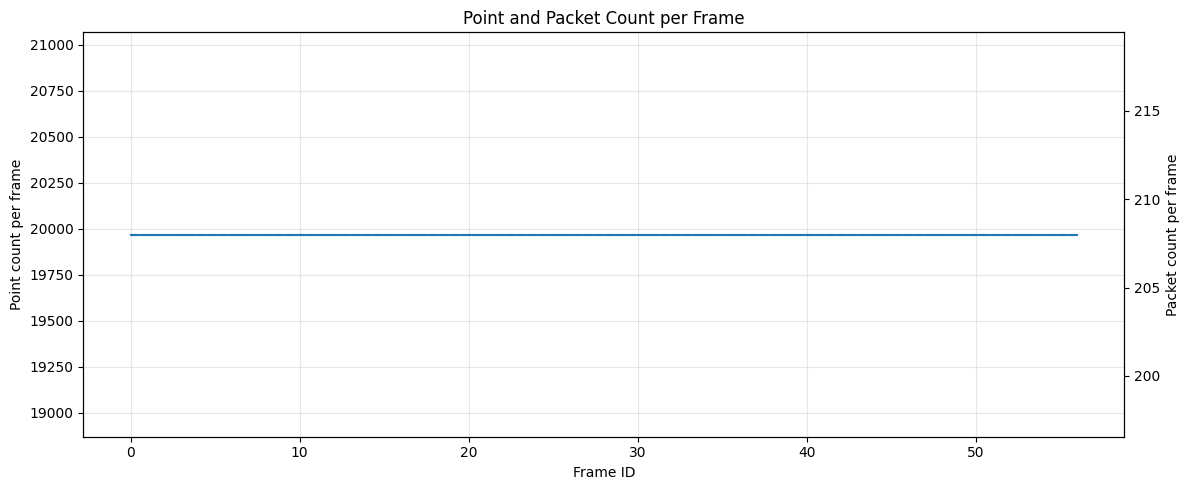

Point count unique values:


,num_frames,count
0,19968,57



Packet count unique values:


,num_frames,count
0,208,57


In [9]:
# =========================
# POINT AND PACKET COUNT OVER FRAME
# =========================

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(frame_summary["frame_id"], frame_summary["point_count"], label="Point count per frame")
ax1.set_xlabel("Frame ID")
ax1.set_ylabel("Point count per frame")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(frame_summary["frame_id"], frame_summary["packet_count"], linestyle="--", label="Packet count per frame")
ax2.set_ylabel("Packet count per frame")

plt.title("Point and Packet Count per Frame")
fig.tight_layout()
plt.show()

print("Point count unique values:")
display(frame_summary["point_count"].value_counts().sort_index().reset_index().rename(
    columns={"index": "point_count", "point_count": "num_frames"}
))

print("\nPacket count unique values:")
display(frame_summary["packet_count"].value_counts().sort_index().reset_index().rename(
    columns={"index": "packet_count", "packet_count": "num_frames"}
))

Cell 9 — Optional: simpan satu frame sebagai HTML

In [10]:
# =========================
# OPTIONAL SAVE ONE FRAME VISUALIZATION TO HTML
# =========================

SAVE_HTML = True

if SAVE_HTML:
    HTML_OUT_DIR = FILE_PATH.parent / "_visualization_html"
    HTML_OUT_DIR.mkdir(parents=True, exist_ok=True)
    
    html_path = HTML_OUT_DIR / f"visual_frame_{DEFAULT_FRAME_ID}.html"
    
    fig = plot_point_cloud_frame(
        frame_id=DEFAULT_FRAME_ID,
        use_roi_filter=USE_ROI_FILTER,
        color_by="Reflectivity",
        max_points=MAX_POINTS_PLOT,
        title_prefix="Framed LiDAR Point Cloud"
    )
    
    if fig is not None:
        fig.write_html(str(html_path))
        print("Saved HTML visualization:", html_path)
else:
    print("SAVE_HTML = False, no file saved.")

Saved HTML visualization: /media/spell/Spell-lab/Lidar/C.Framed Dataset/Dataset Development/Jatuh/Dilia/_visualization_html/visual_frame_28.html
